## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


### Find no.of samples are there in training and test datasets

### Find dimensions of an image in the dataset

In [2]:
print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


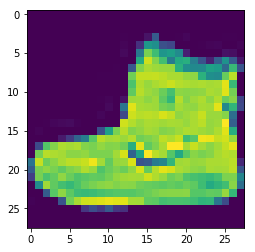

In [3]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
import tensorflow as tf

y_train = tf.keras.utils.to_categorical(y_train,num_classes=10)

In [0]:
y_test = tf.keras.utils.to_categorical(y_test,num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train = x_train.astype('float32') / 255


In [0]:
x_test = x_test.astype('float32') / 255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
tf.keras.backend.clear_session()
#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

In [9]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_train.shape

(60000, 28, 28, 1)

In [10]:
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
x_test.shape

(10000, 28, 28, 1)

### Import the necessary layers from keras to build the model

In [0]:
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [12]:
#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu'))

W0818 11:59:17.437666 140341653309312 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
#Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

In [0]:
#Add dropout layer
model.add(tf.keras.layers.Dropout(0.25))

In [0]:
#Add the Flatten before passing to Dense layers


#Flatten the output
model.add(tf.keras.layers.Flatten())

#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
#early stopping
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

In [19]:
#Train the model
model.fit(x_train,y_train,          
          validation_data=(x_test,y_test),
          epochs=10,
          batch_size=32,
          callbacks=[es])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 11s 188us/sample - loss: 0.3769 - acc: 0.8635 - val_loss: 0.2911 - val_acc: 0.8944
Epoch 2/10
60000/60000 [==============================] - 9s 146us/sample - loss: 0.2417 - acc: 0.9104 - val_loss: 0.2591 - val_acc: 0.9062
Epoch 3/10
60000/60000 [==============================] - 9s 146us/sample - loss: 0.1926 - acc: 0.9262 - val_loss: 0.2451 - val_acc: 0.9106
Epoch 4/10
60000/60000 [==============================] - 9s 148us/sample - loss: 0.1553 - acc: 0.9416 - val_loss: 0.2194 - val_acc: 0.9228
Epoch 5/10
60000/60000 [==============================] - 9s 148us/sample - loss: 0.1247 - acc: 0.9529 - val_loss: 0.2205 - val_acc: 0.9275
Epoch 6/10
60000/60000 [==============================] - 9s 144us/sample - loss: 0.1020 - acc: 0.9615 - val_loss: 0.2545 - val_acc: 0.9209
Epoch 7/10
60000/60000 [==============================] - 9s 144us/sample - loss: 0.0834 - acc: 0.9690 - val_

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              multiple                  320       
_________________________________________________________________
conv2d_1 (Conv2D)            multiple                  18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) multiple                  0         
_________________________________________________________________
dropout (Dropout)            multiple                  0         
_________________________________________________________________
flatten (Flatten)            multiple                  0         
_________________________________________________________________
dense (Dense)                multiple                  1179776   
_________________________________________________________________
dense_1 (Dense)              multiple                  1

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
from keras.preprocessing.image import ImageDataGenerator
batch_size = 32

In [0]:
 datagen = ImageDataGenerator(
      featurewise_center=True,
      featurewise_std_normalization=True,
      rotation_range=20,
      width_shift_range=0.2,
      height_shift_range=0.2,
      horizontal_flip=True)

In [0]:
train_image = datagen.flow(x_train, y_train, batch_size=batch_size)

### Run the above model using fit_generator()

In [24]:
model.fit_generator(train_image, 
                    epochs=10,
                    validation_data=(x_test,y_test))

Epoch 1/10
  19/1875 [..............................] - ETA: 17s - loss: 2.5913 - acc: 0.3043

/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/image_data_generator.py:716: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '
/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/image_data_generator.py:724: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '


1875/1875 [==============================] - 20s 11ms/step - loss: 0.7349 - acc: 0.7277 - val_loss: 0.4086 - val_acc: 0.8487
Epoch 2/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.5331 - acc: 0.8014 - val_loss: 0.3271 - val_acc: 0.8797
Epoch 3/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4870 - acc: 0.8206 - val_loss: 0.3295 - val_acc: 0.8798
Epoch 4/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4591 - acc: 0.8294 - val_loss: 0.3501 - val_acc: 0.8761
Epoch 5/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4355 - acc: 0.8390 - val_loss: 0.3229 - val_acc: 0.8864
Epoch 6/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4187 - acc: 0.8448 - val_loss: 0.3240 - val_acc: 0.8845
Epoch 7/10
1875/1875 [==============================] - 20s 11ms/step - loss: 0.4087 - acc: 0.8494 - val_loss: 0.3275 - val_acc: 0.8856
Epoch 8/10
1875/1875 [==============================] - 20s

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/image_data_generator.py:716: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '
/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/image_data_generator.py:724: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '


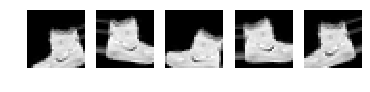

In [25]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

###  Report the final train and validation accuracy

In [26]:
scores = model.evaluate(x_test, y_test, verbose=1)

10000/10000 [==============================] - 1s 83us/sample - loss: 0.3208 - acc: 0.8913


In [27]:
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

Test loss: 0.32078074241876603
Test accuracy: 0.8913


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
from keras.datasets import cifar10

### **Load CIFAR10 dataset**

In [0]:
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

In [30]:
print("X_train shape:", X_train.shape, "Y_train shape:", Y_train.shape)

X_train shape: (50000, 32, 32, 3) Y_train shape: (50000, 1)


In [0]:
import tensorflow as tf
Y_train = tf.keras.utils.to_categorical(Y_train,num_classes=10)

In [0]:
Y_test = tf.keras.utils.to_categorical(Y_test,num_classes=10)

In [0]:
X_test = X_test.astype('float32') / 255

In [0]:
X_train = X_train.astype('float32') / 255

In [35]:
X_train = X_train.reshape(X_train.shape[0], 32, 32, 3)
X_train.shape

(50000, 32, 32, 3)

In [36]:
X_test = X_test.reshape(X_test.shape[0], 32, 32, 3)
X_test.shape

(10000, 32, 32, 3)

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
 data_gen = ImageDataGenerator(
      featurewise_center=True,
      featurewise_std_normalization=True,
      rotation_range=20,
      width_shift_range=0.2,
      height_shift_range=0.2,
      horizontal_flip=True)

### **Prepare/fit the generator.**

In [0]:
data_gen.fit(X_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

W0818 12:04:10.313784 140341653309312 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 12:04:10.328277 140341653309312 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 12:04:10.345937 140341653309312 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 12:04:10.360449 140341653309312 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 12:04:10.376797 140341653309312 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


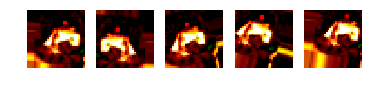

In [39]:
from matplotlib import pyplot as plt
gen = data_gen.flow(X_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze())
    plt.plot()
plt.show()